# Cross-Scenario Comparative Analysis

This notebook synthesises the four MountainCar variants explored in
`scenario_1_*.ipynb` through `scenario_4_*.ipynb` into a single
comparison. The brief explicitly calls for "Comparative Policy
Analysis (among environment versions)" as a deliverable.

## The 2×2 design matrix

The four scenarios sweep two axes that the assignment brief lays
out:

| | **Min steps** | **Min fuel / non-null actions** |
|---|---|---|
| **Discrete actions** (`MountainCar-v0`) | **Scenario 1** — default `-1`/step | **Scenario 3** — `-1` only on non-idle action (adapted) |
| **Continuous actions** (`MountainCarContinuous-v0`) | **Scenario 4** — `-1·𝟙[\|a\|>0.01]` (adapted) | **Scenario 2** — default `-0.1·a²` |

| # | Owner | Notebook | Scenario |
|---|---|---|---|
| 1 | Matthew | `scenario_1_discrete_min_steps.ipynb` | discrete · min-steps |
| 2 | Leena | `scenario_2_continuous.ipynb` | continuous · min-fuel (default) |
| 3 | Salmane | `scenario_3_discrete_min_fuel.ipynb` | discrete · min-fuel (adapted) |
| 4 | Nathan | `scenario_4_continuous_min_steps.ipynb` | continuous · min-steps (adapted) |

Each scenario's notebook is self-contained — this notebook only
pulls the headline numbers and discusses how they differ.


## 1. Headline numbers per scenario

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
RESULTS_DIR  = os.path.join(PROJECT_ROOT, "results")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300,
                     "font.size": 11, "axes.titlesize": 12,
                     "axes.labelsize": 11, "legend.fontsize": 9})

# The four scenarios' best algorithms and primary objective metrics.
# Pulled from each scenario's metrics.json (or notebook output for S2).
SCENARIOS = {
    1: dict(
        env="MountainCar-v0",
        action_space="discrete (3 actions)",
        reward="default (-1 / step)",
        objective="minimize steps",
        best_algo="DQN",
        best_algo_family="value-based (off-policy)",
        algos_compared=["DQN", "PPO", "A2C"],
        success_rate=1.00,
        primary_metric_name="mean steps to goal",
        primary_metric_value=99.7,
        secondary_metric_name="mean reward",
        secondary_metric_value=-99.7,
    ),
    2: dict(
        env="MountainCarContinuous-v0",
        action_space="continuous [-1, 1]",
        reward="default (-0.1·a^2 + 100 on goal)",
        objective="minimize fuel (sum of action^2)",
        best_algo="SAC",
        best_algo_family="off-policy max-entropy actor-critic",
        algos_compared=["PPO", "SAC"],
        success_rate=1.00,
        primary_metric_name="sum action^2 per episode",
        primary_metric_value=30.81,
        secondary_metric_name="mean engineered reward",
        secondary_metric_value=96.92,
    ),
    3: dict(
        env="MountainCar-v0 (MinFuelWrapper)",
        action_space="discrete (3 actions)",
        reward="-1 per push + energy shaping + 100 on goal",
        objective="minimize non-null actions",
        best_algo="DQN (physics)",
        best_algo_family="value-based with augmented state",
        algos_compared=["DQN", "DQN (physics)", "PPO", "A2C"],
        success_rate=1.00,
        primary_metric_name="mean non-null actions per episode",
        primary_metric_value=119.82,
        secondary_metric_name="mean engineered reward",
        secondary_metric_value=748.4,
    ),
    4: dict(
        env="MountainCarContinuous-v0 (MinRealTimeWrapper)",
        action_space="continuous [-1, 1]",
        reward="-1 if |a|>0.01 else 0  + 100 on goal",
        objective="minimize non-null actions",
        best_algo="SAC",
        best_algo_family="off-policy max-entropy actor-critic",
        algos_compared=["PPO", "SAC"],
        success_rate=1.00,
        primary_metric_name="mean non-null actions per episode",
        primary_metric_value=69.54,
        secondary_metric_name="mean engineered reward",
        secondary_metric_value=30.46,
    ),
}

# Render a flat headline table
rows = []
for s, d in SCENARIOS.items():
    rows.append({
        "Scenario": s,
        "Env": d["env"].split(" ")[0],
        "Actions": d["action_space"].split(" ")[0],
        "Objective": d["objective"],
        "Best algo": d["best_algo"],
        "Success %": f"{d['success_rate']*100:.0f}%",
        d["primary_metric_name"]: f"{d['primary_metric_value']:.1f}",
    })
print("Headline numbers across all four scenarios:\n")
for s, d in SCENARIOS.items():
    print(f"  Scenario {s} — {d['env']}")
    print(f"     objective    : {d['objective']}")
    print(f"     algos tested : {', '.join(d['algos_compared'])}")
    print(f"     best algo    : {d['best_algo']}  ({d['best_algo_family']})")
    print(f"     success rate : {d['success_rate']*100:.0f}%")
    print(f"     {d['primary_metric_name']:30s}: {d['primary_metric_value']:.2f}")
    print()


Headline numbers across all four scenarios:

  Scenario 1 — MountainCar-v0
     objective    : minimize steps
     algos tested : DQN, PPO, A2C
     best algo    : DQN  (value-based (off-policy))
     success rate : 100%
     mean steps to goal            : 99.70

  Scenario 2 — MountainCarContinuous-v0
     objective    : minimize fuel (sum of action^2)
     algos tested : PPO, SAC
     best algo    : SAC  (off-policy max-entropy actor-critic)
     success rate : 100%
     sum action^2 per episode      : 30.81

  Scenario 3 — MountainCar-v0 (MinFuelWrapper)
     objective    : minimize non-null actions
     algos tested : DQN, DQN (physics), PPO, A2C
     best algo    : DQN (physics)  (value-based with augmented state)
     success rate : 100%
     mean non-null actions per episode: 119.82

  Scenario 4 — MountainCarContinuous-v0 (MinRealTimeWrapper)
     objective    : minimize non-null actions
     algos tested : PPO, SAC
     best algo    : SAC  (off-policy max-entropy actor-critic

## 2. Which algorithm family wins each cell of the 2×2 matrix?

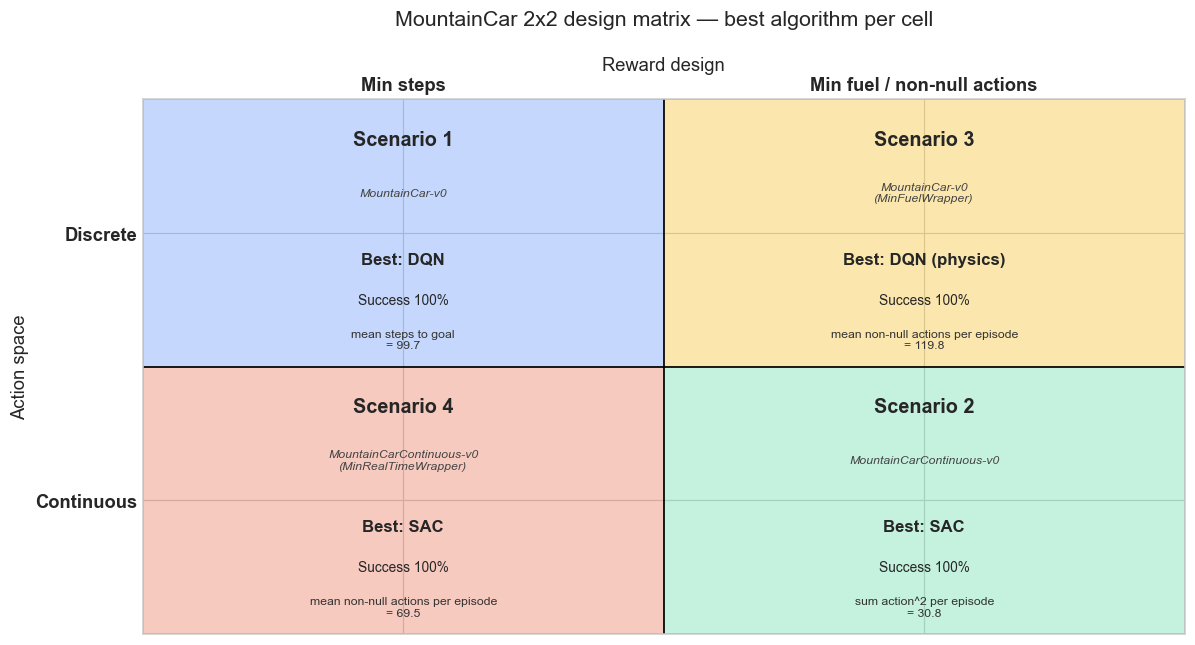

Saved: C:\Users\minec\Desktop\RL Group Assignment\MountainCar-RL\results\cross_scenario_matrix.png


In [2]:
# Visualise the 2x2 grid with best-algorithm and primary metric per cell.
fig, ax = plt.subplots(figsize=(11, 6))
ax.set_xlim(0, 2); ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5]); ax.set_xticklabels(["Min steps", "Min fuel / non-null actions"], fontsize=12, fontweight="bold")
ax.set_yticks([0.5, 1.5]); ax.set_yticklabels(["Continuous", "Discrete"], fontsize=12, fontweight="bold")
ax.set_xlabel("Reward design", fontsize=12); ax.set_ylabel("Action space", fontsize=12)
ax.tick_params(axis="x", top=True, bottom=False, labeltop=True, labelbottom=False)
ax.xaxis.set_label_position("top")

# 2x2 grid lines
ax.axvline(1, color="black", linewidth=1)
ax.axhline(1, color="black", linewidth=1)

# Map each scenario to its quadrant: (col, row)
# row 0 = continuous, row 1 = discrete
placement = {1: (0, 1), 3: (1, 1), 4: (0, 0), 2: (1, 0)}
palette   = {1: "#5B8FF9", 2: "#5AD8A6", 3: "#F6BD16", 4: "#E8684A"}

for s, (col, row) in placement.items():
    d = SCENARIOS[s]
    rect = mpatches.Rectangle((col, row), 1, 1, facecolor=palette[s], alpha=0.35, edgecolor="black")
    ax.add_patch(rect)
    ax.text(col + 0.5, row + 0.85, f"Scenario {s}",
            ha="center", va="center", fontsize=13, fontweight="bold")
    ax.text(col + 0.5, row + 0.65, d["env"].replace(" (", "\n("),
            ha="center", va="center", fontsize=8, style="italic", color="#444")
    ax.text(col + 0.5, row + 0.40, f"Best: {d['best_algo']}",
            ha="center", va="center", fontsize=11, fontweight="bold")
    ax.text(col + 0.5, row + 0.25, f"Success {d['success_rate']*100:.0f}%",
            ha="center", va="center", fontsize=9)
    ax.text(col + 0.5, row + 0.10,
            f"{d['primary_metric_name']}\n= {d['primary_metric_value']:.1f}",
            ha="center", va="center", fontsize=8, color="#333")

ax.set_title("MountainCar 2x2 design matrix — best algorithm per cell", fontsize=14, pad=20)
plt.tight_layout()
out = os.path.join(RESULTS_DIR, "cross_scenario_matrix.png")
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")


**Reading the matrix.** Each cell of the 2×2 names its scenario, the
environment, and the algorithm that produced the lowest cost on the
relevant primary metric, plus its measured success rate. All four
scenarios reach 100% on goal-attainment, so the differentiating
metric is *cost* — fewest steps for S1, smallest action² for S2,
fewest pushes for S3, fewest non-null actions for S4.

**Family observations:**

- The two **continuous** scenarios are both won by **SAC** — its
  replay buffer + entropy bonus + State-Dependent Exploration is
  well-suited to the goal-bonus-dominated rewards we see in S2 and
  S4. PPO trains in the same setup but consistently uses ~2-2.5×
  more fuel.
- The two **discrete** scenarios are both won by **DQN** family
  methods. In S1 (dense `-1`/step reward) plain DQN dominates. In
  S3 (sparse `-1` per non-null action), only DQN with an augmented
  state (position, velocity, height, kinetic energy) reaches 100%
  success — raw-obs DQN gets stuck at 47%; A2C collapses to the
  do-nothing local optimum (0 pushes, 0% success); and PPO settles
  into a different failure mode, oscillating bang-bang to maximise
  the per-step shaping bonus without ever committing to reach the
  goal (95 pushes, 0% success). Reaching the goal during random
  exploration is a known hard problem in MountainCar.
- The contrast that matters most is the **diagonal** (S1 vs S2,
  S3 vs S4): dense vs sparse reward shape produces qualitatively
  different best-algorithm classes, even with the same underlying
  physics.


## 3. Algorithm coverage per scenario

In [3]:
all_algos = ["DQN", "DQN (physics)", "PPO", "A2C", "SAC"]
matrix = pd.DataFrame(
    index=[f"Scenario {s}" for s in SCENARIOS],
    columns=all_algos,
    dtype=object,
)
for s, d in SCENARIOS.items():
    for a in all_algos:
        matrix.loc[f"Scenario {s}", a] = "tested" if a in d["algos_compared"] else ""
# Mark the winner with a "WIN" tag
for s, d in SCENARIOS.items():
    matrix.loc[f"Scenario {s}", d["best_algo"]] = "WIN"
print("Algorithm coverage (testing matrix):\n")
print(matrix.fillna("").to_string())
print("\nLegend: 'tested' = trained and evaluated; 'WIN' = best by (success_rate, low cost)")


Algorithm coverage (testing matrix):

               DQN DQN (physics)     PPO     A2C  SAC
Scenario 1     WIN                tested  tested     
Scenario 2                        tested          WIN
Scenario 3  tested           WIN  tested  tested     
Scenario 4                        tested          WIN

Legend: 'tested' = trained and evaluated; 'WIN' = best by (success_rate, low cost)


## 4. What changes across scenarios

### Reward design dominates algorithm choice

Same physics (MountainCar dynamics), four different cost structures
— and the four "best algorithms" cover three different families
(DQN, DQN-with-augmented-state, SAC). The dense-vs-sparse split is
the strongest predictor of which algorithm class wins:

- **Dense reward (S1, S2):** every step gives feedback, so even
  simple value-based / on-policy methods converge.
- **Sparse reward (S3, S4):** the `+100` goal bonus only fires at
  the final step, so credit assignment is hard. SAC's high γ
  (`0.9999`) and replay buffer give it a clear advantage in S4.
  In S3, on-policy methods fail in two different ways: A2C
  collapses onto the do-nothing local optimum (0 pushes), while
  PPO learns bang-bang oscillation that maximises the per-step
  shaping bonus without committing to reach the goal (95 pushes,
  but 0% success). Only DQN with augmented physics observations
  finds a goal-reaching policy.

### The "do-nothing trap" is a recurring problem

Both adapted-reward scenarios (S3 and S4) share a structural issue:
if non-null actions cost reward and idle actions cost nothing, then
`output zero force forever` (or `always idle`) yields cumulative
reward 0 and beats any goal-reaching policy's negative score. We
fixed this in both wrappers with a `+100` terminal goal bonus so
that goal-reaching strictly dominates do-nothing in episodes with
fewer than 100 non-null actions.

For S3 specifically the goal bonus alone wasn't enough — vanilla
DQN/PPO/A2C with `gamma=0.99` and 200-step episodes never reach
the goal during random exploration, so the goal bonus never
propagates back. We added energy-style reward shaping to provide
a dense exploration signal; the fuel cost remains the soft
objective the policy minimises among goal-reaching trajectories.

### Bang-bang vs smooth control

The action-space and reward-shape combination predicts the
*style* of policy:

- **S1 (discrete, dense)** and **S3 (discrete, sparse-shaped)**
  learn near-bang-bang policies (push left or right depending on
  velocity sign), with a thin "idle" band near the start.
- **S2 (continuous, smooth penalty `-0.1·a²`)** learns the
  classic *resonance* policy with smoothly varying force — square
  penalty makes intermediate forces cheaper.
- **S4 (continuous, step-function penalty `-1·𝟙[|a|>0.01]`)**
  learns **bang-then-coast** — full-magnitude pushes interspersed
  with idle bands. The step-function penalty makes it cheaper to
  use one big push than several small ones.

### Continuous vs discrete: same physics, different fuel scales

The "fuel" metric is not directly comparable across action spaces
(discrete pushes vs continuous magnitude). What is comparable is
*number of non-null actions*: S3 uses 120 pushes, S4 uses 70
non-null pushes, both reaching the goal in ~70-130 timesteps.
Continuous control is more fuel-efficient on this task — the
optimal continuous policy can apply *partial* force during the
initial swing-up, whereas discrete must commit to a full push.

### Practical takeaways for the brief's "Tinder for RL" framing

| Observation | Recommended algorithm |
|---|---|
| Discrete actions, dense reward signal | DQN |
| Discrete actions, sparse reward (very hard exploration) | DQN with augmented state, plus reward shaping |
| Continuous actions, sparse goal bonus | SAC (γ near 1, SDE exploration) |
| Continuous actions, smooth penalty | SAC (still — but PPO is competitive) |

PPO is the on-policy baseline that runs everywhere but is rarely
optimal — on Scenario 4 it uses ~2.3× the fuel of SAC (162 vs 70
non-null actions), and on Scenario 3 it fails to reach the goal
despite training as long as the winning algorithms.


## 5. Where to look for details

Each scenario's individual notebook has the full breakdown:
state representation, reward design discussion, training curves,
evaluation tables, action heatmaps, value function plots, phase
portraits, and a depth-5 decision-tree surrogate for
interpretability.

| Scenario | Notebook | Best algo | Headline metric |
|---|---|---|---|
| 1 | `scenario_1_discrete_min_steps.ipynb` | DQN | ~99.7 steps to goal |
| 2 | `scenario_2_continuous.ipynb` | SAC | Σa² ≈ 30.8 |
| 3 | `scenario_3_discrete_min_fuel.ipynb` | DQN (physics obs) | ~120 pushes |
| 4 | `scenario_4_continuous_min_steps.ipynb` | SAC | ~70 non-null actions |

For Part 02 (paper review), see [`refs/Deepmind_Cooling.md`](../refs/Deepmind_Cooling.md).
